# CIBUSmod Scenario example:<br/>Revisiting scenarios for organic farming in Sweden

This notebook provides an example run of CIBUSmod using two scenarios up until 2050; 'Base20' and 'Sust50' originally developed by Basnet *et al.* (2023).

**Base20:** A business-as-ususal scenario with assumptions on productivity improvements and population growth   
**Sust50:** A scenario with increased organic production (up to 50% of cropland) coupled with stronger productivity gains, reduced food waste and dietary changes towards less animal-source foods


Basnet, S., Wood, A., Röös, E., Jansson, T., Fetzer, I. & Gordon, L. (2023). Organic agriculture in a low-emission world: exploring combined measures to deliver a sustainable food system in Sweden. *Sustainability Science*, 18(1), 501-519. https://doi.org/10.1007/s11625-022-01279-9

## Set things up

Add directory with the CIBUSmod modules to path to be able to import

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

Import CIBUSmod and packages for handling data and plotting

In [2]:
import CIBUSmod as cm
import CIBUSmod.utils.plot as plot

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Instantiate a `Session` object and define scenarios.

In [3]:
years = list(range(2020,2050+1,5))

# Create session
session = cm.Session(
    name = 'example_scenarios',
    data_path = '../data'
)

# Define scenarios
session.add_scenario(
    name = 'Base20',
    scenario_workbooks = 'example_bau',
    years = years
)

# Define scenarios
session.add_scenario(
    name = 'Sust50',
    scenario_workbooks = ['example_bau', 'example_org_circ'],
    years = years
)

Define some styling for plots

In [4]:
bar_style = {
    'ticklabels_fontsize' : 9,
    'grouplabels_fontsize' : 9,
    'ylabel_fontsize' : 10,
    'xlabel_fontsize' : 10,
    'cmap' : 'YlGnBu'
}

## Run calculations
The code below initiates a process pool that executes the model runs. The `max_workers` paramter to `ProcessPoolExecutor()` defines the maximum number of concurrent processes. The ideal value for this will depend on the computer. The code will print a message every time a scenario run has finnished and if a scenario run fails it will print an error message.

In [5]:
# Import
from concurrent.futures import ProcessPoolExecutor, as_completed
from multi_proc import do_run
import traceback

# Create list of scenarios/years to run
runs = [(s,y) for s, y in session.iterate('all')]
runs
# runs = [('Sust50','2050')]

[('Base20', '2020'),
 ('Base20', '2025'),
 ('Base20', '2030'),
 ('Base20', '2035'),
 ('Base20', '2040'),
 ('Base20', '2045'),
 ('Base20', '2050'),
 ('Sust50', '2020'),
 ('Sust50', '2025'),
 ('Sust50', '2030'),
 ('Sust50', '2035'),
 ('Sust50', '2040'),
 ('Sust50', '2045'),
 ('Sust50', '2050')]

In [6]:
%%time

# Do the multi-processing
with ProcessPoolExecutor(max_workers=8) as executor:
    
    futures = {executor.submit(do_run, session, scn_year) : scn_year for scn_year in runs}

    for future in as_completed(futures):
    
        scn, year = futures[future]
           
        try:
            t = future.result()
        except Exception as ee:
            print(f'(!!!) {scn}, {year} failed with the exception: {ee}')
        else:
            m = int(t/60)
            s = int(round(t - m*60))
            
            print(f'{scn}, {year} finished successfully in {m}min {s}s')
                    

Base20, 2020 finished successfully in 4min 25s
Base20, 2030 finished successfully in 4min 27s
Base20, 2035 finished successfully in 4min 48s
Sust50, 2020 finished successfully in 4min 50s
Base20, 2045 finished successfully in 4min 57s
Base20, 2040 finished successfully in 5min 0s
Base20, 2025 finished successfully in 5min 1s
Base20, 2050 finished successfully in 5min 3s
Sust50, 2025 finished successfully in 2min 52s
Sust50, 2030 finished successfully in 3min 6s
Sust50, 2035 finished successfully in 3min 17s
Sust50, 2050 finished successfully in 3min 8s
Sust50, 2045 finished successfully in 3min 13s
Sust50, 2040 finished successfully in 3min 25s
CPU times: total: 15.6 ms
Wall time: 8min 19s


## Plot output

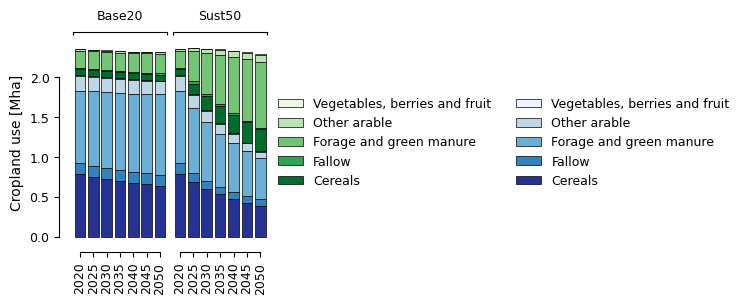

prod_system  conventional    organic  total
scn    year                                
Base20 2020     86.100469  13.899531  100.0
       2025     85.812129  14.187871  100.0
       2030     85.545823  14.454177  100.0
       2035     85.305494  14.694506  100.0
       2040     85.072618  14.927382  100.0
       2045     84.850385  15.149615  100.0
       2050     84.657736  15.342264  100.0
Sust50 2020     86.100469  13.899531  100.0
       2025     75.562418  24.437582  100.0
       2030     67.387201  32.612799  100.0
       2035     60.856823  39.143177  100.0
       2040     55.453500  44.546500  100.0
       2045     50.942764  49.057236  100.0
       2050     47.110543  52.889457  100.0

prod_system  conventional   organic     total
scn    year                                  
Base20 2020      2.027228  0.327263  2.354491
       2025      2.013744  0.332945  2.346689
       2030      1.999947  0.337919  2.337866
       2035      1.986461  0.342183  2.328644
       2040      1.976461  0.346802  2.323263
       2045      1.969010  0.351557  2.320567
       2050      1.960757  0.355342  2.316098
Sust50 2020      2.027228  0.327263  2.354491
       2025      1.791107  0.579260  2.370367
       2030      1.590949  0.769958  2.360907
       2035      1.430494  0.920095  2.350589
       2040      1.295460  1.040659  2.336119
       2045      1.180667  1.136968  2.317635
       2050      1.078549  1.210852  2.289401

In [7]:
plot_data = (
    session.get_attr('c','area',{'prod_system':None, 'crop':['land_use','crop_group2']})
    .loc[:,(slice(None),'cropland')]
    .droplevel('land_use', axis=1)
    .rename(columns={'Fodder crops':'Forage and green manure'})
)/1_000_000

from matplotlib.colors import ListedColormap
colors = ['#253494', '#3182bd', '#6baed6','#bdd7e7' , '#eff3ff',
          '#006d2c', '#31a354', '#74c476', '#bae4b3', '#edf8e9']
cust_cmap = ListedColormap(name='X', colors=colors)

fig, ax = plt.subplots(figsize=(2.5,2.5))
cm.plot.bar(
    plot_data.droplevel('prod_system', axis=1),
    ax=ax,
    group_levels='scn',
    sort_categories=False,
    ylabel='Cropland use [Mha]',
    **{k:v for k,v in bar_style.items() if k != 'cmap'},
    cmap=cust_cmap
)
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=2, fontsize=9, frameon=False, reverse=True)
plt.show()

tab_data = plot_data.T.groupby('prod_system').sum().T
tab_data['total'] = tab_data.sum(axis=1)
display(tab_data.apply(lambda x: x/x.total*100, axis=1))
display(tab_data)

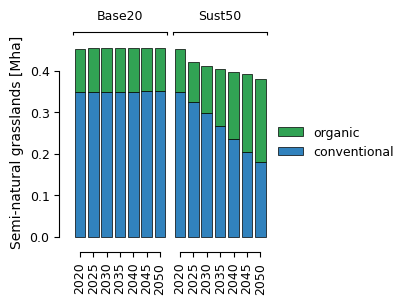

In [8]:
plot_data = (
    session.get_attr('c','area',{'prod_system':None, 'crop':'land_use'})
    .loc[:,(slice(None),'semi-natural grasslands')]
    .droplevel('land_use', axis=1)
)/1_000_000

from matplotlib.colors import ListedColormap
colors = ['#3182bd','#31a354']
cust_cmap = ListedColormap(name='X', colors=colors)

fig, ax = plt.subplots(figsize=(2.5,2.5))
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    sort_categories=False,
    ylabel='Semi-natural grasslands [Mha]',
    **{k:v for k,v in bar_style.items() if k != 'cmap'},
    cmap=cust_cmap
)
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1, fontsize=9, frameon=False, reverse=True)
plt.show()

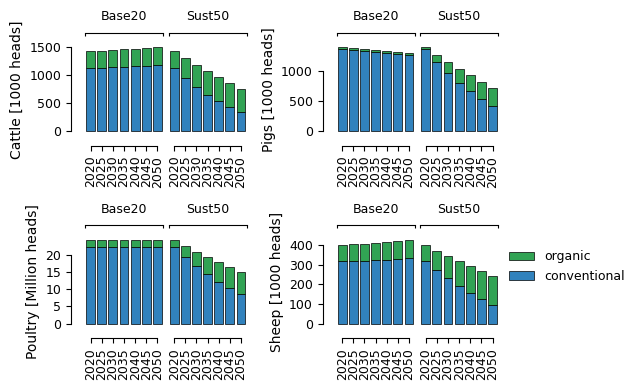

In [9]:
# Number of animal heads
plot_data = session.get_attr('A','heads',['species','prod_system'])

from matplotlib.colors import ListedColormap
colors = ['#3182bd','#31a354']
cust_cmap = ListedColormap(name='X', colors=colors)

fig, axs = plt.subplots(2,2, figsize=(6.5,4))

for ax,sp in zip(axs.flatten(),plot_data.drop('horses', axis=1).columns.get_level_values('species').unique()):

    cm.plot.bar(
        (plot_data / (1000000 if sp=='poultry' else 1000))
        .xs(sp, level='species', axis=1),
        **{k:v for k,v in bar_style.items() if k != 'cmap'},
        cmap=cust_cmap,
        ax=ax,
        group_levels='scn',
        ylabel=sp.capitalize() + (' [Million heads]' if sp=='poultry' else ' [1000 heads]')
    )

for ax in axs.flatten():
    ax.legend().set_visible(False)
ax.legend(loc='upper left', ncol=1, bbox_to_anchor=(1, 1), fontsize=9, frameon=False, reverse=True)

plt.tight_layout()
plt.show()

In [10]:
d = (
    session.get_attr('c','harvest',{'crop':['land_use',None],'prod_system':None})/
    session.get_attr('c','area',{'crop':['land_use',None],'prod_system':None})
).loc[[('Base20','2020'),('Base20','2050'),('Sust50','2050')],'cropland'] / 1_000

display(d.T.xs('conventional', level='prod_system', drop_level=False))
display(d.T.xs('organic', level='prod_system', drop_level=False))

scn                                                  Base20             \
year                                                   2020       2050   
crop                                prod_system                          
Apples                              conventional  18.341441  21.214879   
Barley, spring                      conventional   5.011251   5.974321   
Barley, winter                      conventional   6.371792   7.593095   
Beans, dry                          conventional   1.771157   1.768864   
Broad beans and horse beans, dry    conventional   3.288914   4.123896   
Buckwheat                           conventional   1.865106   1.660549   
Cabbages, cauliflowers and broccoli conventional  21.685775  27.105903   
Carrots                             conventional  67.405331  85.560708   
Cereals for fodder                  conventional   3.492660   3.496603   
Cucumbers                           conventional  62.124539  63.439060   
Currants                            conventional   1.479149   1.501637   
Energy grass                        conventional   4.026451   4.027127   
Fallow                              conventional   2.333292   2.331821   
Green manure                        conventional   4.808647   4.809145   
Herbs                               conventional   4.010174   5.099862   
Lettuce and spinach                 conventional  15.535112  19.693449   
Ley for fodder                      conventional   5.505731   5.519328   
Ley for grazing                     conventional   4.456469   4.486252   
Ley for seed                        conventional   0.650000   0.650000   
Ley not harvested                   conventional   3.972764   3.970473   
Maize (corn)                        conventional   6.096836   6.101068   
Maize for forage and silage         conventional  10.799012  10.760149   
Mixed cereals                       conventional   3.325068   3.298424   
Oats                                conventional   4.616728   5.747149   
Onions                              conventional  51.313992  65.056202   
Other berries                       conventional   1.689706   1.766983   
Other crops for fodder              conventional   4.333427   4.345815   
Other fruit                         conventional   4.566211   4.587298   
Other root vegetables               conventional  34.864153  43.970183   
Other vegetables                    conventional  14.942488  18.563246   
Pears                               conventional  15.645672  15.710540   
Peas, dry                           conventional   3.411177   4.267608   
Peas, green                         conventional   4.405018   4.421994   
Potatoes, starch                    conventional  45.169104  55.111164   
Potatoes, table                     conventional  38.294366  46.639726   
Pumpkins and squash                 conventional  27.210757  34.112795   
Quinoa                              conventional   1.305022   1.305022   
Rapeseed, spring                    conventional   1.836120   2.198589   
Rapeseed, winter                    conventional   3.554188   4.259217   
Rye                                 conventional   6.902911   8.623990   
Short rotation coppice              conventional   4.694914   4.694562   
Strawberries                        conventional   6.877322   6.887888   
Sugar beet                          conventional  76.508937  95.607454   
Triticale, spring                   conventional   3.307525   3.314277   
Triticale, winter                   conventional   5.753824   5.754469   
Wheat, spring                       conventional   4.629528   6.300168   
Wheat, winter                       conventional   7.246938   9.906368   

scn                                                   Sust50  
year                                                    2050  
crop                                prod_system               
Apples                              conventional   25.084825  
Barley, spring                      conventiona

scn                                              Base20                Sust50
year                                               2020       2050       2050
crop                             prod_system                                 
Apples                           organic       8.110380   8.105811   8.179621
Barley, spring                   organic       3.164292   3.266395   4.573532
Barley, winter                   organic       3.964937   4.084277   4.390324
Beans, dry                       organic       1.401524   1.695912   1.877359
Broad beans and horse beans, dry organic       2.348655   2.710352   3.527618
Buckwheat                        organic       1.512245  12.672125   0.784501
Carrots                          organic      58.650285  74.528878  80.800444
Cereals for fodder               organic       3.081181   3.080049   3.005670
Cucumbers                        organic      10.481964  13.309913  14.187710
Energy grass                     organic       3.567358   3.567666   4.209516
Fallow                           organic       2.240712   2.238231   2.122902
Green manure                     organic       4.500789   4.499723   4.715611
Herbs                            organic       0.876809   1.113531   0.411189
Lettuce and spinach              organic       5.840467   7.418623   8.086338
Ley for fodder                   organic       4.728248   4.732947   4.641600
Ley for grazing                  organic       3.804951   3.825310   3.674577
Ley for seed                     organic       0.400000   0.400000   0.400000
Ley not harvested                organic       3.542399   3.542392   3.347449
Maize (corn)                     organic       3.940218   3.940782   4.111819
Mixed cereals                    organic       2.697339   2.724256   4.238454
Oats                             organic       2.994105   3.116816   4.164470
Onions                           organic      25.815672  32.788673  35.986768
Other crops for fodder           organic       3.578871   3.584332   3.304600
Other root vegetables            organic       7.246370   9.204325  10.215517
Other vegetables                 organic       3.171410   4.025948   4.534493
Pears                            organic       5.474707   5.472762   5.528670
Peas, dry                        organic       2.619214   3.028737   3.549874
Potatoes, starch                 organic            NaN        NaN  42.243089
Potatoes, table                  organic      26.004092  31.918956  35.143545
Rapeseed, spring                 organic       0.729739   0.966754   1.213352
Rapeseed, winter                 organic       2.133724   2.839695   3.242087
Rye                              organic       3.850813   5.405882   6.854124
Short rotation coppice           organic       4.475785   4.469247   4.877954
Triticale, spring                organic       2.102664   2.105453        NaN
Triticale, winter                organic       4.223303   4.223917   4.488917
Wheat, spring                    organic       2.909084   3.621739   4.186934
Wheat, winter                    organic       4.415014   5.506444   5.944465

scn     year
Base20  2020     0.769193
        2025     0.756754
        2030     0.745967
        2035     0.736722
        2040     0.726897
        2045     0.717056
        2050     0.709409
Sust50  2020     0.769193
        2025    10.698837
        2030    16.034653
        2035    19.567509
        2040    22.180157
        2045    24.239676
        2050    24.223806
Name: Green manure, dtype: float64

scn     year
Base20  2020    146.683219
        2025    145.322846
        2030    143.937125
        2035    142.539164
        2040    141.314882
        2045    140.211219
        2050    139.039493
Sust50  2020    146.683219
        2025    135.182238
        2030    124.382196
        2035    114.393258
        2040    105.478913
        2045     97.567276
        2050     90.944371
Name: value, dtype: float64

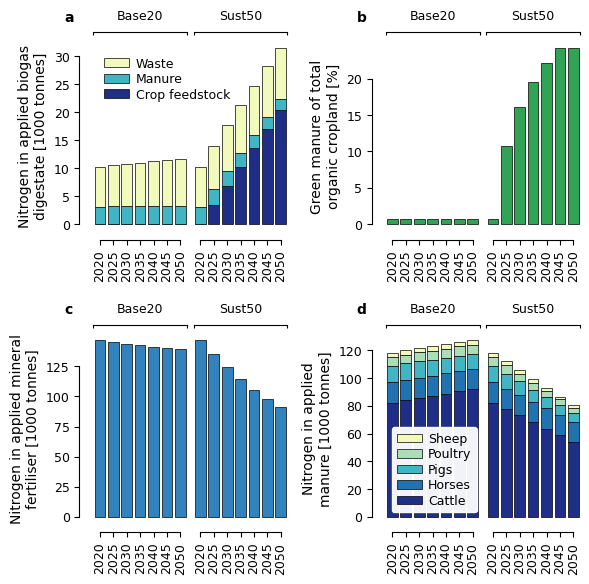

In [11]:
fig, axs = plt.subplots(2,2, figsize=(6,6))

from matplotlib.colors import ListedColormap

plot_data = (
    session.get_attr('w','organic_fertiliser_N','feedstock_type')
    .rename(columns = lambda x: 'Waste' if 'waste' in x else x.capitalize())
    .T.groupby('feedstock_type').sum().T
)/1_000_000

# fig, ax = plt.subplots(figsize=(2.5,2.5))
ax=axs[0,0]
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    ylabel='Nitrogen in applied biogas\ndigestate [1000 tonnes]',
    **bar_style
)
legend = ax.legend(
    loc='upper left', bbox_to_anchor=(0, 1),
    ncol=1,
    fontsize=9, handletextpad=0.5, labelspacing=0.2,
    frameon=False,
    reverse=True
)
# plt.show()

plot_data = session.get_attr('c','area',{'prod_system':None,'crop':['land_use',None]}).loc[:,('organic','cropland')].apply(lambda x: x/x.sum()*100, axis=1).loc[:,'Green manure']

colors = ['#31a354']
cust_cmap = ListedColormap(name='X', colors=colors)

# fig, ax = plt.subplots(figsize=(2.5,2.5))
ax=axs[0,1]
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    ylabel='Green manure of total\norganic cropland [%]',
    **{k:v for k,v in bar_style.items() if k != 'cmap'},
    cmap=cust_cmap
)
# plt.show()

display(plot_data)

plot_data = (
    session.get_attr('c','fertiliser.mineral_N','none')
)/1_000_000

colors = ['#3182bd']
cust_cmap = ListedColormap(name='X', colors=colors)

# fig, ax = plt.subplots(figsize=(2.5,2.5))
ax=axs[1,0]
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    ylabel='Nitrogen in applied mineral\nfertiliser [1000 tonnes]',
    **{k:v for k,v in bar_style.items() if k != 'cmap'},
    cmap=cust_cmap
)
ax.legend().set_visible(False)
# plt.show()
display(plot_data)

plot_data = (
    session.get_attr('c','fertiliser.manure_N','species')
    .rename(columns = lambda x: x.capitalize())
)/1_000_000

# fig, ax = plt.subplots(figsize=(2.5,2.5))
ax=axs[1,1]
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    ylabel='Nitrogen in applied\nmanure [1000 tonnes]',
    **bar_style
)
# ax.legend(loc='lower left', bbox_to_anchor=(0, 0), ncol=1, fontsize=9, frameon=True, reverse=True)
legend = ax.legend(
    loc='lower left', bbox_to_anchor=(0, 0),
    ncol=1,
    fontsize=9, handletextpad=0.5, labelspacing=0.2,
    frameon=True,
    reverse=True
)
legend.get_frame().set_edgecolor('white')
# legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.95)
# plt.show()

# Annotate
for i, ax in enumerate(axs.flat):
    ax.text(-0.15, 1.2, chr(97 + i), transform=ax.transAxes, 
            fontsize=10, fontweight='bold', va='top', ha='left')

plt.tight_layout()
plt.show()

In [12]:
session.get_attr('c','fertiliser.mineral_N','prod_system').add(
    session.get_attr('c','fertiliser.manure_N','prod_system')+session.get_attr('c','fertiliser.organic_N','prod_system'),
    fill_value=0
)/1_000_000

prod_system  conventional    organic
scn    year                         
Base20 2020    251.434268  23.884715
       2025    251.767507  24.254648
       2030    251.850075  24.586276
       2035    251.726223  24.868430
       2040    251.855971  25.175544
       2045    252.131628  25.493997
       2050    252.137305  25.759253
Sust50 2020    251.434268  23.884715
       2025    227.904432  33.324749
       2030    206.810987  40.913043
       2035    188.017221  46.818420
       2040    171.320940  51.783281
       2045    156.223761  56.146248
       2050    142.216374  60.492127

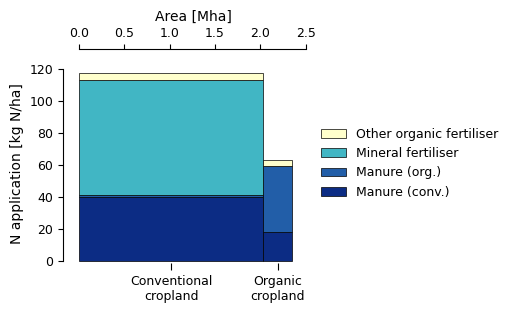

,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser,total
prod_system,,,,,
Conventional\ncropland,40.53149,0.696441,72.278618,4.416826,117.923375
Organic\ncropland,18.31487,41.075827,NaN,4.058348,63.449045


,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser
prod_system,,,,
Conventional\ncropland,33.790152,0.580606,60.256986,3.682204
Organic\ncropland,28.717357,64.406091,NaN,6.363411


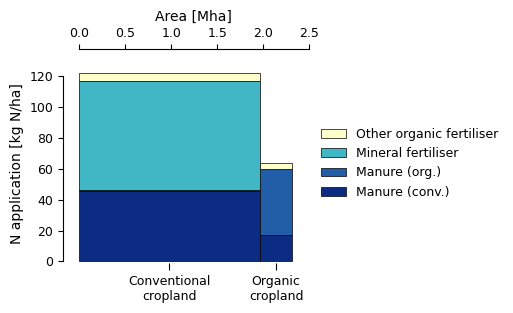

,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser,total
prod_system,,,,,
Conventional\ncropland,45.383795,0.827676,70.812696,5.231169,122.255336
Organic\ncropland,17.196175,42.631673,NaN,3.860486,63.688335


,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser
prod_system,,,,
Conventional\ncropland,36.536164,0.666320,57.007667,4.211346
Organic\ncropland,26.850700,66.566561,NaN,6.027896


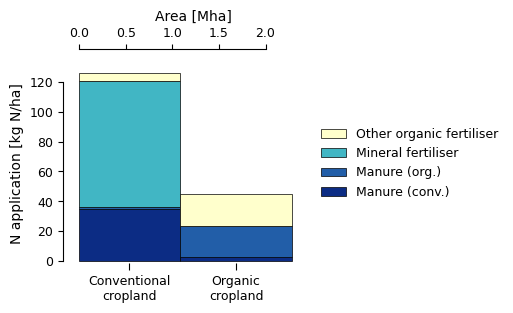

,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser,total
prod_system,,,,,
Conventional\ncropland,34.686050,1.318775,84.166769,5.801791,125.973385
Organic\ncropland,2.798597,21.128460,NaN,20.813644,44.740700


,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser
prod_system,,,,
Conventional\ncropland,27.300687,1.037981,66.245956,4.566472
Organic\ncropland,6.090321,45.979861,NaN,45.294756


In [13]:
scn = 'SCN'

for scn, year in [('Base20','2020'),('Base20','2050'),('Sust50','2050')]:
    mi = (
        session.get_attr('c','fertiliser.mineral_N',{'crop':'land_use','prod_system':None}).loc[(scn,year),'cropland']
    )
    ma = (
        session.get_attr('c','fertiliser.manure_N',{'crop':'land_use','prod_system':None, 'animal_prod_system':None}).loc[(scn,year),'cropland']
        .unstack()
        .rename(columns={'conventional':'Manure (conv.)', 'organic':'Manure (org.)'})
    )
    
    oo = (
        session.get_attr('c','fertiliser.organic_N',{'crop':'land_use','prod_system':None}).loc[(scn,year),'cropland']
    )
    
    ar = (
        session.get_attr('c','area',{'crop':'land_use', 'prod_system':None}).loc[(scn,year),'cropland']
    )
    
    plot_data = pd.concat([
        ma.div(ar, axis=0),
        mi.div(ar, axis=0).rename('Mineral fertiliser'),
        oo.div(ar, axis=0).rename('Other organic fertiliser'),
        ar.rename('area')/1_000_000
    ], axis=1).rename(index={'conventional':'Conventional\ncropland','organic':'Organic\ncropland'})
    
    from matplotlib.colors import ListedColormap
    colors = ['#0c2c84', '#225ea8', '#41b6c4', '#ffffcc']
    cust_cmap = ListedColormap(name='X', colors=colors)
    
    fig, ax = plt.subplots(figsize=(3,2.6))
    
    cm.plot.marimekko(
        plot_data.fillna(0),
        ax=ax,
        x_column='area',
        cmap=cust_cmap,
        sort_categories=False,
        xlim_pad = 0.08,
        ylim_pad = 0.05,
        xcategorylabels_rotation=0,
        xcategorylabels_halign='center',
        ylabel='N application [kg N/ha]',
        xlabel='Area [Mha]',
        ylabel_fontsize=10,
        xlabel_fontsize=10,
        ticklabels_fontsize=9,
        xcategorylabels_fontsize=9
    )
    
    ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9, frameon=False, reverse=True)
    
    plt.show()
    fig.savefig(os.path.join(session.data_path_output,'figs',f'N-boxes {scn}_{year}.pdf'), format='pdf', bbox_inches="tight")

    table_data = plot_data.drop('area', axis=1)
    table_data['total'] = table_data.sum(axis=1)
    display(table_data)
    display(plot_data.div(plot_data.sum(axis=1), axis=0).drop('area', axis=1)*100)

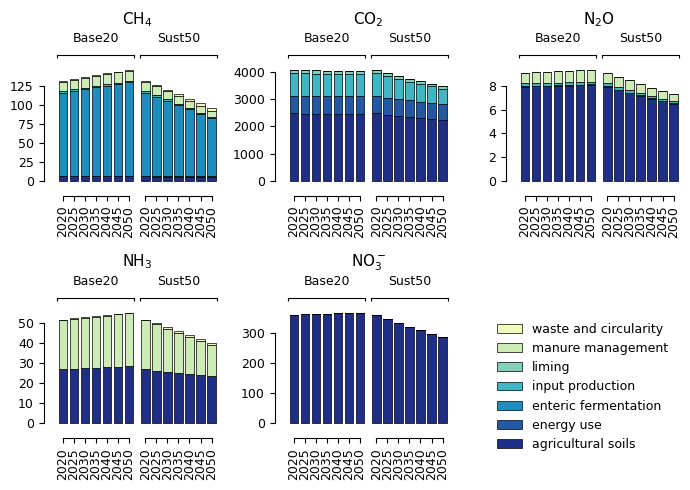

In [20]:
to_comp = {
    'CO2' : 1,
    'CH4bio' : 1,
    'CH4fos' : 1,
    'N2O' : 1,
    'N2O-N' : (44/28),
    'NH3' : 1,
    'NH3-N' : (17/14),
    'NO3-N' : (62/14),
    'NOx' : 1
}

to_comp_names = {
    'N2O' : 'N$_2$O',
    'CO2' : 'CO$_2$',
    'CH4bio' : 'CH$_4$',
    'CH4fos' : 'CH$_4$',
    'N2O-N' : 'N$_2$O',
    'NH3' : 'NH$_3$',
    'NH3-N' : 'NH$_3$',
    'NO3-N' : 'NO$_3^-$',
    'NOx' : 'NO$_X$'
}

ems = (
    cm.impact.get_emissions(session)
    .drop(['NOx-N','CO2bio','N2','NOx'], level='compound', axis=1)
)

plot_data = (
    ems
    .mul([to_comp[cp] for cp in ems.columns.get_level_values('compound')], axis=1)
    .rename(to_comp_names, axis=1)
    .T.groupby(['compound','process']).sum().T
    .stack().unstack().fillna(0)
)/1_000_000

fig, axs = plt.subplots(2,3, figsize=(7,5))
for i, cmp in enumerate(plot_data.columns.unique('compound')):
    ax = axs.flatten()[i]
    cm.plot.bar(
        plot_data.loc[:,cmp],
        group_levels='scn',
        ax=ax,
        **bar_style
    )
    ax.set_title(cmp, fontsize=11)

handles, labels = ax.get_legend_handles_labels()
ax = axs.flatten()[-1]
ax.legend(handles, labels, fontsize=9, frameon=False, reverse=True)
ax.axis('off')

for ax in axs.flatten()[:-1]:
    ax.legend().set_visible(False)

plt.tight_layout()
plt.show()

tab_data = plot_data.T.groupby('compound').sum().T
# tab_data['CO$_2$eq'] = tab_data.mul(pd.Series({'CO$_2$':1, 'CH$_4$':25, 'N$_2$O':298}), axis=1).sum(axis=1)
display((tab_data.div(tab_data.loc[('Base20','2020')], axis=1)*100-100).style.format(precision=0))

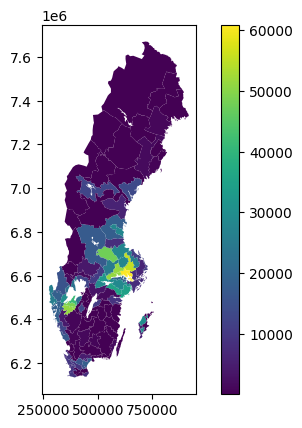

In [21]:
cm.plot.map_from_series(
    session.get_attr('c','area',{'crop':'land_use','prod_system':None,'region':None}).loc[('Sust50','2050'),('cropland','organic')]
)

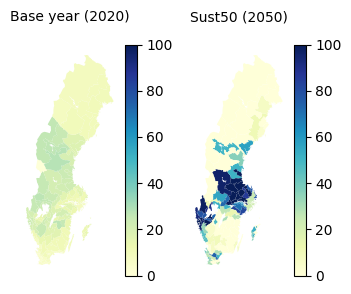

In [22]:
plot_data = (
    session.get_attr('c','area',{'crop':'land_use','region':None,'prod_system':None})
    .loc[:,'cropland']
    .T.groupby('region')
    .apply(lambda x: x/x.sum()*100).xs('organic', level='prod_system')
    .droplevel(0).T
)

fig, axs = plt.subplots(1,2, figsize=(4,3))

ax=axs[0]
cm.plot.map_from_series(
    plot_data.loc[('Sust50','2020')],
    vmin=0,
    vmax=100,
    cmap='YlGnBu',
    ax=ax
)
ax.axis('off')
ax.set_title('Base year (2020)', fontsize=10)

ax=axs[1]
cm.plot.map_from_series(
    plot_data.loc[('Sust50','2050')],
    vmin=0,
    vmax=100,
    cmap='YlGnBu',
    ax=ax
)
ax.axis('off')
ax.set_title('Sust50 (2050)', fontsize=10)

plt.show()

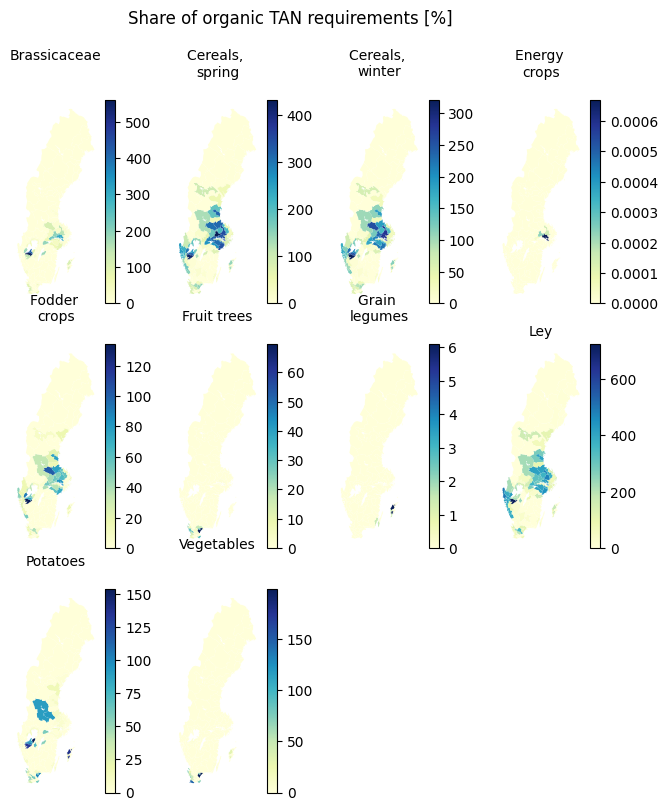

In [23]:
plot_data = (
    session.get_attr('c','fertiliser.TAN_req',{'crop':['land_use','crop_group'],'region':None,'prod_system':None})
    .xs(('cropland','organic'), level=('land_use', 'prod_system'), axis=1)
    # .T.groupby('region')
    # .apply(lambda x: x/x.sum()*100)
    # .droplevel(0).T
)/1000

fig, axs = cm.plot.subplots(
    plot_data.loc[('Sust50','2050')],
    index = 'crop_group',
    plot_fn = cm.plot.map_from_series,
    size=(2, 3),
    title_fontsize=10,
    cmap='YlGnBu'
)
for ax in axs.flatten():
    ax.axis('off')
fig.suptitle('Share of organic TAN requirements [%]')
plt.show()

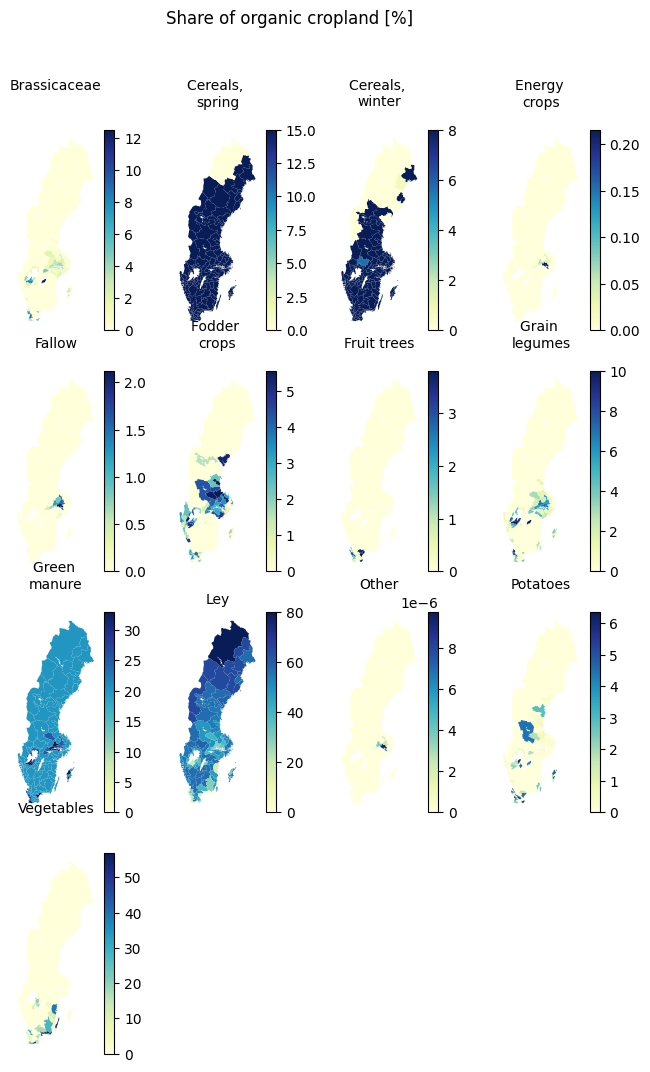

In [24]:
plot_data = (
    session.get_attr('c','area',{'crop':['land_use','crop_group'],'region':None,'prod_system':None})
    .xs(('cropland','organic'), level=('land_use', 'prod_system'), axis=1)
    .T.groupby('region')
    .apply(lambda x: x/x.sum()*100)
    .droplevel(0).T
)

fig, axs = cm.plot.subplots(
    plot_data.loc[('Sust50','2050')],
    index = 'crop_group',
    plot_fn = cm.plot.map_from_series,
    size=(2, 3),
    title_fontsize=10,
    vmin=0,
    cmap='YlGnBu'
)
for ax in axs.flatten():
    ax.axis('off')
fig.suptitle('Share of organic cropland [%]')
plt.show()

In [25]:
session.get_attr('c','fertiliser.crop_residues_N_soil_loss',['crop']).apply(lambda x: x/x.sum()*100, axis=1).loc[:,'Green manure']

scn     year
Base20  2020     0.156441
        2025     0.154413
        2030     0.152603
        2035     0.150972
        2040     0.149262
        2045     0.147551
        2050     0.146080
Sust50  2020     0.156441
        2025     2.872853
        2030     5.592012
        2035     8.059482
        2040    10.255766
        2045    12.193448
        2050    13.070758
Name: Green manure, dtype: float64

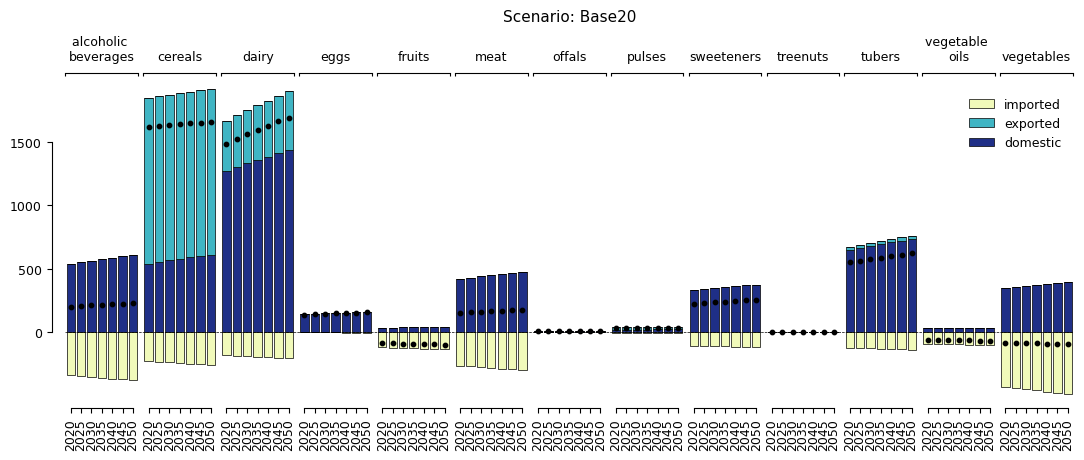

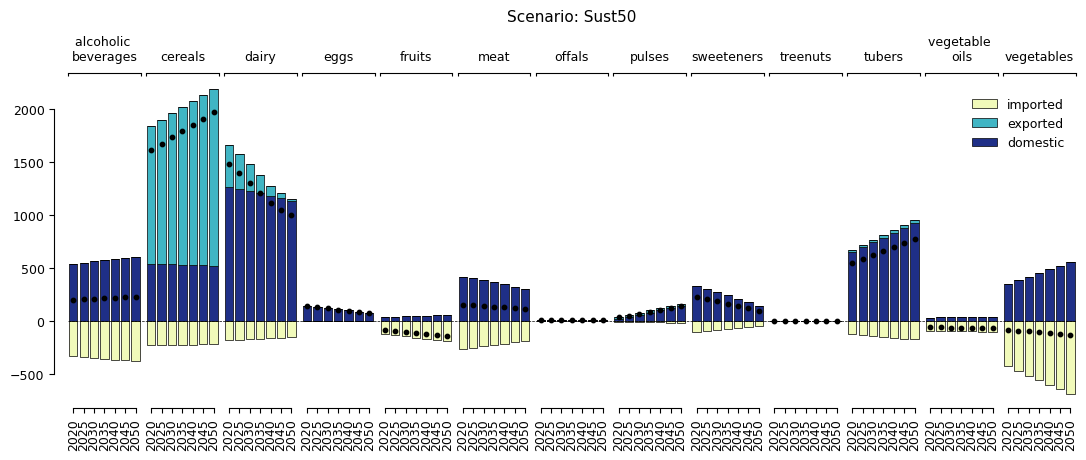

In [26]:
plot_data = (
    session.get_attr(
        module='D',
        attr='food_demand_to_processing',
        groupby=['origin','food_group']
    ).add(
        session.get_attr(
            module='D',
            attr='export_demand',
            groupby=['origin','food_group']
        ).rename(columns={'domestic':'exported'}),
        fill_value = 0
    )
    .stack()
    .fillna(0)
)/1000000
plot_data.loc[:,'imported'] = -plot_data.loc[:,'imported']

for scn in session.scenarios():
    fig, ax = plt.subplots(figsize=(13,4))
    cm.plot.bar(plot_data.loc[scn], group_levels='food_group', grouptitle=f'Scenario: {scn}', ax=ax, **bar_style)
    plt.show()